## Feature Engineering

5. Engineer at least 8 features from the main table: 
   - CREDIT_INCOME_RATIO = AMT_CREDIT / AMT_INCOME_TOTAL 
   - ANNUITY_INCOME_RATIO = AMT_ANNUITY / AMT_INCOME_TOTAL 
   - CREDIT_TERM = AMT_ANNUITY / AMT_CREDIT (proxy for loan term) 
   - DAYS_EMPLOYED_RATIO = DAYS_EMPLOYED / DAYS_BIRTH 
   - INCOME_PER_PERSON = AMT_INCOME_TOTAL / CNT_FAM_MEMBERS 
   - EXT_SOURCE_MEAN = mean of EXT_SOURCE_1, EXT_SOURCE_2, EXT_SOURCE_3 
   - EXT_SOURCE_STD = std of EXT_SOURCE_1, EXT_SOURCE_2, EXT_SOURCE_3 
   - AGE_BUCKET = pd.cut(age, bins=[20,30,40,50,60,70,100]) 
6. Engineer at least 4 aggregation features from bureau.csv: 
   - Count of bureau records, count of active credits, mean of DAYS_CREDIT, max of AMT_CREDIT_SUM_OVERDUE 
   - Re-run correlation analysis, engineered features should have higher correlation than original features to TARGET
   - Test for multicollinearity, drop features that have r>0.95
7. Encode categorical variables: ordinal for NAME_EDUCATION_TYPE (ordered), one-hot for others 
with <10 categories. Drop high-cardinality categoricals (>50 categories) or use frequency encoding. 
8. Save the final preprocessed DataFrame to data/preprocessed_train.csv.

### Load data

In [43]:
import numpy as np
import pandas as pd
from pathlib import Path
import os

In [44]:
clean_train_path = Path(f"{os.getcwd()}/../data/application_train_cleaned.csv")
df = pd.read_csv(clean_train_path)

In [45]:
display(df.head())
display(df.info())
display(df.describe())

,Unnamed: 0,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,...,AMT_REQ_CREDIT_BUREAU_YEAR,missingness_DAYS_EMPLOYED,missingness_OCCUPATION_TYPE,missingness_EXT_SOURCE_3,missingness_AMT_REQ_CREDIT_BUREAU_HOUR,missingness_AMT_REQ_CREDIT_BUREAU_DAY,missingness_AMT_REQ_CREDIT_BUREAU_WEEK,missingness_AMT_REQ_CREDIT_BUREAU_MON,missingness_AMT_REQ_CREDIT_BUREAU_QRT,missingness_AMT_REQ_CREDIT_BUREAU_YEAR
0,71,100083,0,Cash loans,M,Y,Y,0,103500.0,573628.5,...,3.0,0,0,0,0,0,0,0,0,0
1,124,100145,0,Cash loans,F,Y,Y,1,202500.0,260725.5,...,3.0,0,0,0,0,0,0,0,0,0
2,143,100165,0,Cash loans,F,Y,Y,0,175500.0,1293502.5,...,2.0,1,1,0,0,0,0,0,0,0
3,152,100179,0,Cash loans,F,Y,N,0,202500.0,675000.0,...,4.0,0,0,0,0,0,0,0,0,0
4,161,100190,0,Cash loans,M,Y,N,0,162000.0,263686.5,...,3.0,0,0,0,0,0,0,0,0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12968 entries, 0 to 12967
Columns: 132 entries, Unnamed: 0 to missingness_AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(66), int64(50), object(16)
memory usage: 13.1+ MB


None

,Unnamed: 0,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,...,AMT_REQ_CREDIT_BUREAU_YEAR,missingness_DAYS_EMPLOYED,missingness_OCCUPATION_TYPE,missingness_EXT_SOURCE_3,missingness_AMT_REQ_CREDIT_BUREAU_HOUR,missingness_AMT_REQ_CREDIT_BUREAU_DAY,missingness_AMT_REQ_CREDIT_BUREAU_WEEK,missingness_AMT_REQ_CREDIT_BUREAU_MON,missingness_AMT_REQ_CREDIT_BUREAU_QRT,missingness_AMT_REQ_CREDIT_BUREAU_YEAR
count,12968.000000,12968.000000,12968.000000,12968.000000,1.296800e+04,1.296800e+04,12968.000000,1.296800e+04,12968.000000,12968.000000,...,11702.000000,12968.000000,12968.000000,12968.000000,12968.000000,12968.000000,12968.000000,12968.000000,12968.000000,12968.000000
mean,153995.736814,278458.833359,0.060302,0.570481,2.199984e+05,7.023502e+05,31764.294147,6.366832e+05,0.024367,-14421.510487,...,1.750555,0.053131,0.212060,0.153146,0.097625,0.097625,0.097625,0.097625,0.097625,0.097625
std,88976.658150,103028.854790,0.238055,0.763939,1.411020e+05,4.678843e+05,17039.997690,4.331356e+05,0.017097,3570.484520,...,1.778737,0.224303,0.408783,0.360142,0.296818,0.296818,0.296818,0.296818,0.296818,0.296818
min,71.000000,100083.000000,0.000000,0.000000,2.816100e+04,4.500000e+04,2317.500000,4.500000e+04,0.000290,-25018.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,76133.500000,188292.500000,0.000000,0.000000,1.350000e+05,3.150000e+05,19614.375000,2.700000e+05,0.010643,-16728.500000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,153912.500000,278379.000000,0.000000,0.000000,1.800000e+05,5.850000e+05,29250.000000,4.950000e+05,0.020246,-13977.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,232029.500000,368754.000000,0.000000,1.000000,2.700000e+05,9.611460e+05,40546.125000,9.000000e+05,0.031329,-11632.750000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,307482.000000,456226.000000,1.000000,5.000000,4.500000e+06,4.050000e+06,225000.000000,4.050000e+06,0.072508,-7695.000000,...,17.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### 5. Engineer 8 new features

In [46]:
# first re-add age column
df['age'] = abs(df['DAYS_BIRTH'] / 365)

# credit income ratio
df['CREDIT_INCOME_RATIO'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']

# annuity income ratio
df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']

# credit term
df['CREDIT_TERM'] = df['AMT_ANNUITY'] / df['AMT_CREDIT']

# days employed ratio
df['DAYS_EMPLOYED_RATIO'] = df['DAYS_EMPLOYED'] / df['DAYS_BIRTH']

# income per person
df['INCOME_PER_PERSON'] = df['AMT_INCOME_TOTAL'] / df['CNT_FAM_MEMBERS']

# ext source mean
df['EXT_SOURCE_MEAN'] = df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].mean(axis=1)

# ext source standard deviation
df['EXT_SOURCE_STD'] = df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].std(axis=1)

# age bucket/bins
df['AGE_BUCKET'] = pd.cut(df['age'], bins=[20,30,40,50,60,70,100])

engineered_features = ['age', 'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_TERM', 'DAYS_EMPLOYED_RATIO', 'INCOME_PER_PERSON', 'EXT_SOURCE_MEAN', 'EXT_SOURCE_STD', 'AGE_BUCKET']

### 6. Engineer aggregation features (Count of bureau records, count of active credits, mean of DAYS_CREDIT, max of AMT_CREDIT_SUM_OVERDUE)

In [47]:
# read in bureau dataset
bureau_path = Path(f"{os.getcwd()}/../data/bureau.csv")
bureau_df = pd.read_csv(bureau_path)

Since we want the number of active credit loans for each customer, it does not suffice to simply count the number of entries for CREDIT_ACTIVE, since this is a categorical column indicating whether that credit loan is open/closed. We'll convert this to binary column then sum up the Trues/the 1s

In [48]:
# make active credit column
bureau_df['CREDIT_IS_ACTIVE'] = bureau_df['CREDIT_ACTIVE'].apply(lambda x: 1 if x == 'Active' else 0)
bureau_df

,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY,CREDIT_IS_ACTIVE
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.00,0.0,NaN,0.0,Consumer credit,-131,NaN,0
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.00,171342.0,NaN,0.0,Credit card,-20,NaN,1
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.50,NaN,NaN,0.0,Consumer credit,-16,NaN,1
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.00,NaN,NaN,0.0,Credit card,-16,NaN,1
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.00,NaN,NaN,0.0,Consumer credit,-21,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1716423,259355,5057750,Active,currency 1,-44,0,-30.0,NaN,0.0,0,11250.00,11250.0,0.0,0.0,Microloan,-19,NaN,1
1716424,100044,5057754,Closed,currency 1,-2648,0,-2433.0,-2493.0,5476.5,0,38130.84,0.0,0.0,0.0,Consumer credit,-2493,NaN,0
1716425,100044,5057762,Closed,currency 1,-1809,0,-1628.0,-970.0,NaN,0,15570.00,NaN,NaN,0.0,Consumer credit,-967,NaN,0
1716426,246829,5057770,Closed,currency 1,-1878,0,-1513.0,-1513.0,NaN,0,36000.00,0.0,0.0,0.0,Consumer credit,-1508,NaN,0


In [49]:
agg_features = bureau_df.groupby(by=['SK_ID_CURR']).agg(
    bureau_records=('SK_ID_BUREAU', 'count'), 
    num_active_credits=('CREDIT_IS_ACTIVE', 'sum'), 
    mean_days_credit=('DAYS_CREDIT', 'mean'), 
    max_credit_sum_overdue=('AMT_CREDIT_SUM_OVERDUE', 'max')).reset_index()

display(agg_features)

,SK_ID_CURR,bureau_records,num_active_credits,mean_days_credit,max_credit_sum_overdue
0,100001,7,3,-735.000000,0.0
1,100002,8,2,-874.000000,0.0
2,100003,4,1,-1400.750000,0.0
3,100004,2,0,-867.000000,0.0
4,100005,3,2,-190.666667,0.0
...,...,...,...,...,...
305806,456249,13,2,-1667.076923,0.0
305807,456250,3,2,-862.000000,0.0
305808,456253,4,2,-867.500000,0.0
305809,456254,1,0,-1104.000000,0.0


Now, we'll join back to the original dataframe to enrich the dataset with the aggregated features at the customer level. We use a left join since we want to retain all customers, then we'll deal with the nulls accordingly later

In [50]:
# join back to original df
df = df.merge(agg_features, how='left', on='SK_ID_CURR')

In [51]:
df.head()

,Unnamed: 0,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,...,CREDIT_TERM,DAYS_EMPLOYED_RATIO,INCOME_PER_PERSON,EXT_SOURCE_MEAN,EXT_SOURCE_STD,AGE_BUCKET,bureau_records,num_active_credits,mean_days_credit,max_credit_sum_overdue
0,71,100083,0,Cash loans,M,Y,Y,0,103500.0,573628.5,...,0.042597,0.057900,51750.0,0.525028,0.226954,"(40, 50]",2.0,1.0,-1229.000000,0.0
1,124,100145,0,Cash loans,F,Y,Y,1,202500.0,260725.5,...,0.064395,0.268702,101250.0,0.710981,0.055483,"(40, 50]",7.0,3.0,-1489.714286,0.0
2,143,100165,0,Cash loans,F,Y,Y,0,175500.0,1293502.5,...,0.027497,NaN,87750.0,0.663539,0.141612,"(60, 70]",2.0,0.0,-1775.000000,0.0
3,152,100179,0,Cash loans,F,Y,N,0,202500.0,675000.0,...,0.079007,0.203165,101250.0,0.654939,0.033591,"(30, 40]",2.0,0.0,-1325.000000,0.0
4,161,100190,0,Cash loans,M,Y,N,0,162000.0,263686.5,...,0.093981,0.320069,81000.0,0.636513,0.134213,"(30, 40]",5.0,2.0,-1215.800000,0.0


Now, the join introduces some new nulls to the dataset after having engineered features. Let's deal with these as follows
- For count features, NaN means that there is no count, or that the count is 0, e.g. BUREAU_COUNT = 0 means that there were 0 bureau records
- For max features, a max of NaN aligns with a max of 0, e.g. nonexistnet max of amount of credit overdue essentially means 0
- For mean features, we'll use the median, since it won't be easily affected by extreme values

In [52]:
df["bureau_records"] = df["bureau_records"].fillna(0)
df["num_active_credits"] = df["num_active_credits"].fillna(0)
df["max_credit_sum_overdue"] = df["max_credit_sum_overdue"].fillna(0)
df["mean_days_credit"] = df["mean_days_credit"].fillna(df["mean_days_credit"].median())

engineered_features += ['bureau_records', 'num_active_credits', 'mean_days_credit', 'max_credit_sum_overdue']

### 7. Encode categorical variables

First we'll drop categorical features that have high cardinality (>50\%) -- this is just noise

In [53]:
# first find all high cardinality variables
display(df.select_dtypes(include='object').nunique().sort_values(ascending=False))
categorical_cols = df.select_dtypes(include='object').nunique().sort_values(ascending=False).index

ORGANIZATION_TYPE             57
OCCUPATION_TYPE               18
NAME_TYPE_SUITE                7
WEEKDAY_APPR_PROCESS_START     7
WALLSMATERIAL_MODE             7
NAME_HOUSING_TYPE              6
NAME_INCOME_TYPE               5
NAME_EDUCATION_TYPE            5
NAME_FAMILY_STATUS             5
FONDKAPREMONT_MODE             4
CODE_GENDER                    3
HOUSETYPE_MODE                 3
NAME_CONTRACT_TYPE             2
FLAG_OWN_REALTY                2
EMERGENCYSTATE_MODE            2
FLAG_OWN_CAR                   1
dtype: int64

Of these, `ORGANIZATION_TYPE` has high cardinality - drop it

In [54]:
df = df.drop(columns=['ORGANIZATION_TYPE'])

Next, we'll encode the `NAME_EDUCATION_TYPE` using ordinal encoding

In [55]:
df['NAME_EDUCATION_TYPE'].unique()

engineered_features += ['NAME_EDUCATION_TYPE']

In [56]:
# define a mapping
education_mapping = {
    'Lower secondary': 1,
    'Secondary / secondary special': 2,
    'Incomplete higher': 3,
    'Higher education': 4,
    'Academic degree': 5
}

In [57]:
df['NAME_EDUCATION_TYPE'] = df['NAME_EDUCATION_TYPE'].map(education_mapping)
display(df.head(20)['NAME_EDUCATION_TYPE'])

0     2
1     2
2     2
3     4
4     4
5     2
6     2
7     2
8     3
9     2
10    2
11    4
12    4
13    2
14    4
15    2
16    4
17    4
18    4
19    2
Name: NAME_EDUCATION_TYPE, dtype: int64

Now, we'll do one-hot encoding on the columns that remain

In [58]:
categorical_cols = categorical_cols.drop(['ORGANIZATION_TYPE', 'NAME_EDUCATION_TYPE'])
display(categorical_cols)   

Index(['OCCUPATION_TYPE', 'NAME_TYPE_SUITE', 'WEEKDAY_APPR_PROCESS_START',
       'WALLSMATERIAL_MODE', 'NAME_HOUSING_TYPE', 'NAME_INCOME_TYPE',
       'NAME_FAMILY_STATUS', 'FONDKAPREMONT_MODE', 'CODE_GENDER',
       'HOUSETYPE_MODE', 'NAME_CONTRACT_TYPE', 'FLAG_OWN_REALTY',
       'EMERGENCYSTATE_MODE', 'FLAG_OWN_CAR'],
      dtype='object')

In [59]:
one_hot_encoded = pd.get_dummies(df[categorical_cols], dtype=int)
display(one_hot_encoded.head())

,OCCUPATION_TYPE_Accountants,OCCUPATION_TYPE_Cleaning staff,OCCUPATION_TYPE_Cooking staff,OCCUPATION_TYPE_Core staff,OCCUPATION_TYPE_Drivers,OCCUPATION_TYPE_HR staff,OCCUPATION_TYPE_High skill tech staff,OCCUPATION_TYPE_IT staff,OCCUPATION_TYPE_Laborers,OCCUPATION_TYPE_Low-skill Laborers,...,HOUSETYPE_MODE_block of flats,HOUSETYPE_MODE_specific housing,HOUSETYPE_MODE_terraced house,NAME_CONTRACT_TYPE_Cash loans,NAME_CONTRACT_TYPE_Revolving loans,FLAG_OWN_REALTY_N,FLAG_OWN_REALTY_Y,EMERGENCYSTATE_MODE_No,EMERGENCYSTATE_MODE_Yes,FLAG_OWN_CAR_Y
0,0,0,0,0,0,0,0,0,1,0,...,1,0,0,1,0,0,1,1,0,1
1,0,0,0,0,0,0,0,0,1,0,...,1,0,0,1,0,0,1,1,0,1
2,0,0,0,0,0,0,0,0,0,0,...,1,0,0,1,0,0,1,1,0,1
3,0,0,0,0,0,0,0,0,0,0,...,1,0,0,1,0,1,0,1,0,1
4,0,0,0,0,0,0,0,0,1,0,...,1,0,0,1,0,1,0,1,0,1


In [60]:
# concat back with original df, drop original categorical columns
df = pd.concat([df, one_hot_encoded], axis=1).drop(columns=categorical_cols)
display(df.head())

# engineered_features += list(one_hot_encoded.columns)

,Unnamed: 0,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_EDUCATION_TYPE,REGION_POPULATION_RELATIVE,...,HOUSETYPE_MODE_block of flats,HOUSETYPE_MODE_specific housing,HOUSETYPE_MODE_terraced house,NAME_CONTRACT_TYPE_Cash loans,NAME_CONTRACT_TYPE_Revolving loans,FLAG_OWN_REALTY_N,FLAG_OWN_REALTY_Y,EMERGENCYSTATE_MODE_No,EMERGENCYSTATE_MODE_Yes,FLAG_OWN_CAR_Y
0,71,100083,0,0,103500.0,573628.5,24435.0,463500.0,2,0.009657,...,1,0,0,1,0,0,1,1,0,1
1,124,100145,0,1,202500.0,260725.5,16789.5,198000.0,2,0.018850,...,1,0,0,1,0,0,1,1,0,1
2,143,100165,0,0,175500.0,1293502.5,35568.0,1129500.0,2,0.018850,...,1,0,0,1,0,0,1,1,0,1
3,152,100179,0,0,202500.0,675000.0,53329.5,675000.0,4,0.031329,...,1,0,0,1,0,1,0,1,0,1
4,161,100190,0,0,162000.0,263686.5,24781.5,238500.0,4,0.022625,...,1,0,0,1,0,1,0,1,0,1


### Re-run correlation analysis

In [61]:
fts = df.drop(columns=['TARGET'])
target_correlation = fts.corrwith(df['TARGET'], numeric_only=True).sort_values(ascending=False).head(30)
display(target_correlation)

mean_days_credit                           0.068032
REGION_RATING_CLIENT_W_CITY                0.063431
EXT_SOURCE_STD                             0.060833
DAYS_EMPLOYED                              0.057491
REGION_RATING_CLIENT                       0.054966
FLAG_DOCUMENT_3                            0.053968
num_active_credits                         0.052266
DAYS_BIRTH                                 0.049022
NAME_INCOME_TYPE_Working                   0.046422
NAME_CONTRACT_TYPE_Cash loans              0.045560
ANNUITY_INCOME_RATIO                       0.044355
OWN_CAR_AGE                                0.041118
CODE_GENDER_M                              0.036896
OCCUPATION_TYPE_Laborers                   0.036199
NAME_INCOME_TYPE_Unemployed                0.034666
AMT_REQ_CREDIT_BUREAU_YEAR                 0.033901
DAYS_ID_PUBLISH                            0.032631
NAME_HOUSING_TYPE_With parents             0.030804
NAME_FAMILY_STATUS_Single / not married    0.028463
OCCUPATION_T

### Testing for multicollinearity

<Axes: >

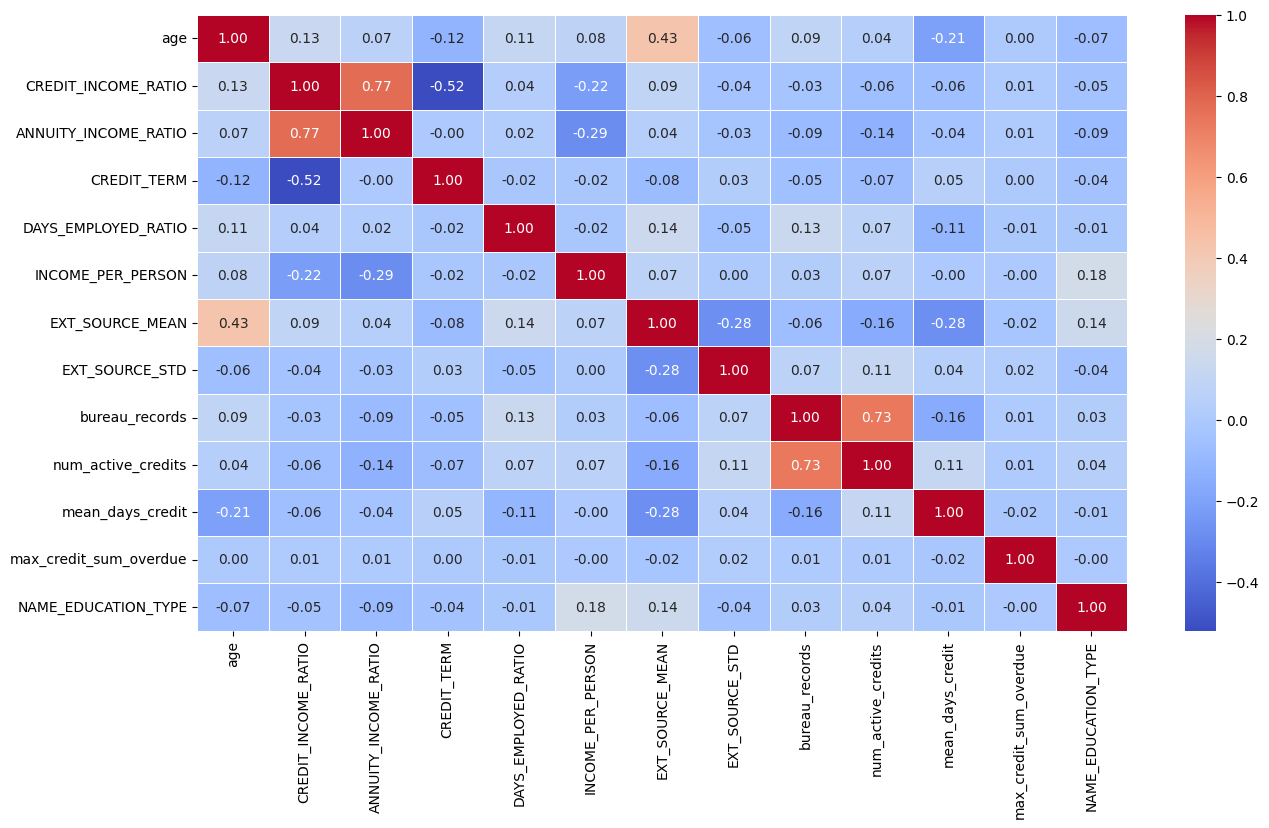

In [62]:
engineered_features_df = df[engineered_features]
corr_matrix = engineered_features_df.corr(numeric_only=True)

import seaborn as sns
import matplotlib.pyplot as plt
# plot heatmap
plt.figure(figsize=(15,8))
sns.heatmap(data=corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

### Save preprocessed dataframe

In [63]:
preprocessed_path = Path(f"{os.getcwd()}/../data/preprocessed_train.csv")
df.to_csv(preprocessed_path, index=False)